In [1]:
!pip install roboflow --quiet


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from zipfile import ZipFile
from tqdm.notebook import tqdm
import requests
import shutil  # 用於檔案移動和刪除

# 檢查是否已安裝 Roboflow API
try:
    from roboflow import Roboflow
    print("Roboflow API 已安裝。")
except ImportError:
    print("Roboflow API 未安裝，正在安裝...")
    %pip install roboflow --quiet  # 使用 %pip 避免輸出過多信息
    from roboflow import Roboflow
    print("Roboflow API 安裝完成。")

# 定義 Roboflow 專案資訊
# 請替換為您的 Roboflow API Key
ROBOCFLOW_API_KEY = "zUOGhrkluWYOWp9tExDN"
ROBOCFLOW_WORKSPACE = "swinburne-k9jvx"
ROBOCFLOW_PROJECT = "bird-species-24ksx"
ROBOCFLOW_VERSION = 3
DATASET_FORMAT = "multiclass"  # 下載為多類別分類格式

extract_dir_birds = "bird_species_data"  # 解壓縮後的目標資料夾

# 檢查資料集是否已存在
# 我們檢查其中一個目標子資料夾是否存在來判斷
# Roboflow 下載的 multiclass 格式通常會在根目錄下建立 train/valid/test 資料夾
test_class_path = os.path.join(extract_dir_birds, 'train', 'AMERICAN CROW')

if not os.path.exists(test_class_path):
    print(f"正在從 Roboflow 下載資料集：{ROBOCFLOW_PROJECT} v{ROBOCFLOW_VERSION}...")
    try:
        rf = Roboflow(api_key=ROBOCFLOW_API_KEY)
        project = rf.workspace(ROBOCFLOW_WORKSPACE).project(ROBOCFLOW_PROJECT)
        # 下載資料集到 'bird_species_data' 資料夾
        dataset = project.version(ROBOCFLOW_VERSION).download(DATASET_FORMAT, location=extract_dir_birds)
        print(f"{ROBOCFLOW_PROJECT} v{ROBOCFLOW_VERSION} 資料集下載完成並解壓縮到 {extract_dir_birds}。")
    except Exception as e:
        print(f"從 Roboflow 下載資料時發生錯誤：{e}")
        print("請確保您的 Roboflow API 金鑰正確，且有權限訪問該資料集。")
else:
    print(f"鳥類圖片已存在於 {extract_dir_birds}，跳過下載。")


Roboflow API 已安裝。
正在從 Roboflow 下載資料集：bird-species-24ksx v3...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to bird_species_data in multiclass:: 100%|██████████| 13128/13128 [00:04<00:00, 2839.61it/s]


bird-species-24ksx v3 資料集下載完成並解壓縮到 bird_species_data。


In [3]:
from tensorflow.keras.preprocessing.image import load_img  # 確保可用

# 你感興趣的鳥類類別（跟檔名前綴相同，注意大小寫）
bird_classes_english = ['Acadian_Flycatcher', 'Blue_Jay', 'House_Sparrow']
bird_classes_chinese = ['褐翅鹟', '冠藍鴉', '麻雀']
num_classes = len(bird_classes_english)

print(f"Selected {num_classes} bird classes:")
for i, (cls_en, cls_cn) in enumerate(zip(bird_classes_english, bird_classes_chinese)):
    print(f"\t{i}: {cls_en} ({cls_cn})")

all_image_paths = []
all_image_labels = []

train_data_root = os.path.join(extract_dir_birds, 'train')

if not os.path.exists(train_data_root):
    print(f"Error: Training data root directory {train_data_root} does not exist. Please check download step.")
else:
    print("\nScanning train directory and filtering images by class:")
    all_files = [f for f in os.listdir(train_data_root) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    all_files.sort()
    
    for f in all_files:
        # 檔名前綴為類別名稱，例如 'Acadian_Flycatcher_0035_886796969_jpg.rf...jpg'
        prefix = f.split('_')[0]  # 這只取第一段，可能不夠完整，改用前兩段試試
        prefix2 = '_'.join(f.split('_')[:2])  # 改用前兩段
        # 用前兩段來判斷類別名稱
        if prefix2 in bird_classes_english:
            label_idx = bird_classes_english.index(prefix2)
            all_image_paths.append(os.path.join(train_data_root, f))
            all_image_labels.append(label_idx)

    # 顯示結果
    for i, cls in enumerate(bird_classes_english):
        count = sum([1 for lbl in all_image_labels if lbl == i])
        print(f"  {cls} ({bird_classes_chinese[i]}): {count} images")
        # 列出前三張圖片檔名
        images_for_class = [p for p, lbl in zip(all_image_paths, all_image_labels) if lbl == i]
        for img_path in images_for_class[:3]:
            print(f"\t- {os.path.basename(img_path)}")
        if count > 3:
            print("\t...")

print(f"\nTotal images found: {len(all_image_paths)}.")
if not all_image_paths:
    print("Warning: No bird images found, subsequent examples may not run correctly.")


Selected 3 bird classes:
	0: Acadian_Flycatcher (褐翅鹟)
	1: Blue_Jay (冠藍鴉)
	2: House_Sparrow (麻雀)

Scanning train directory and filtering images by class:
  Acadian_Flycatcher (褐翅鹟): 0 images
  Blue_Jay (冠藍鴉): 36 images
	- Blue_Jay_0012_2240062272_jpg.rf.39df140cda70a29920cdf3062c38a175.jpg
	- Blue_Jay_0012_2240062272_jpg.rf.c43cdc1bff6c95b9d2b4429689eb14c9.jpg
	- Blue_Jay_0012_2240062272_jpg.rf.e232c22ec85c161b112319a27f700d1c.jpg
	...
  House_Sparrow (麻雀): 73 images
	- House_Sparrow_0001_128704753_jpg.rf.4c956a0c685370d6d855b0f6f742d874.jpg
	- House_Sparrow_0001_128704753_jpg.rf.6475b34a4b4f26f66a4fc90abcec0c28.jpg
	- House_Sparrow_0001_128704753_jpg.rf.a3b9b9533e191ab364841f2b4c23e726.jpg
	...

Total images found: 109.


In [4]:
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from tqdm.notebook import tqdm
import numpy as np

# 定義圖片尺寸 (ResNet50V2 預設輸入尺寸)
IMG_HEIGHT = 224
IMG_WIDTH = 224

# 儲存所有圖片資料和標籤的列表
data = []
targets = []

print(f"\nLoading and preprocessing images (resizing to {IMG_HEIGHT}x{IMG_WIDTH})...")
# 遍歷所有圖片路徑和對應標籤
for img_path, label in tqdm(zip(all_image_paths, all_image_labels), total=len(all_image_paths), desc="Loading and preprocessing images"):
    try:
        # 載入圖片並調整大小
        img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        # 將圖片轉換為 NumPy 陣列
        img_array = img_to_array(img)
        # 將像素值正規化到 0-1 之間
        img_array = img_array / 255.0
        data.append(img_array)
        targets.append(label)
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")

# 將列表轉換為 NumPy 陣列
data = np.array(data)
targets = np.array(targets)

print(f"Data shape (data.shape): {data.shape}")
print(f"Labels shape (targets.shape): {targets.shape}")

# 將標籤進行 One-Hot Encoding
# 如果類別是 0, 1, 2，經過 One-Hot Encoding 後會變成 [1,0,0], [0,1,0], [0,0,1]
one_hot_targets = to_categorical(targets, num_classes=num_classes)
print(f"One-Hot encoded labels shape (one_hot_targets.shape): {one_hot_targets.shape}")
print("\nFirst 5 One-Hot encoded label examples:")
for i in range(min(5, len(one_hot_targets))):
    print(f"\tOriginal Label: {targets[i]}, One-Hot: {one_hot_targets[i]}")



Loading and preprocessing images (resizing to 224x224)...


Loading and preprocessing images:   0%|          | 0/109 [00:00<?, ?it/s]

Data shape (data.shape): (109, 224, 224, 3)
Labels shape (targets.shape): (109,)
One-Hot encoded labels shape (one_hot_targets.shape): (109, 3)

First 5 One-Hot encoded label examples:
	Original Label: 1, One-Hot: [0. 1. 0.]
	Original Label: 1, One-Hot: [0. 1. 0.]
	Original Label: 1, One-Hot: [0. 1. 0.]
	Original Label: 1, One-Hot: [0. 1. 0.]
	Original Label: 1, One-Hot: [0. 1. 0.]


In [5]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model

# 設定影像尺寸與類別數
IMG_SIZE = (224, 224)
NUM_CLASSES = 3  # Acadian_Flycatcher, Blue_Jay, House_Sparrow

# 預訓練模型：不包含最上層（分類層），使用 imagenet 權重
base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# 冻结 base_model 的所有層（可微調時再開）
base_model.trainable = False

# 建構新頂部分類層
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)  # 將輸入傳給 base_model
x = GlobalAveragePooling2D()(x)         # 壓縮特徵圖
x = Dropout(0.3)(x)                      # Dropout 防止過擬合
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# 組合模型
model = Model(inputs, outputs)

# 模型摘要
model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,570,947 (89.92 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
# 訓練模型
history = model.fit(
    data,
    one_hot_targets,
    epochs=5,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.8391 - loss: 0.3359 - val_accuracy: 1.0000 - val_loss: 0.0734
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.9885 - loss: 0.0503 - val_accuracy: 0.9545 - val_loss: 0.0833
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0507
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0382
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0293


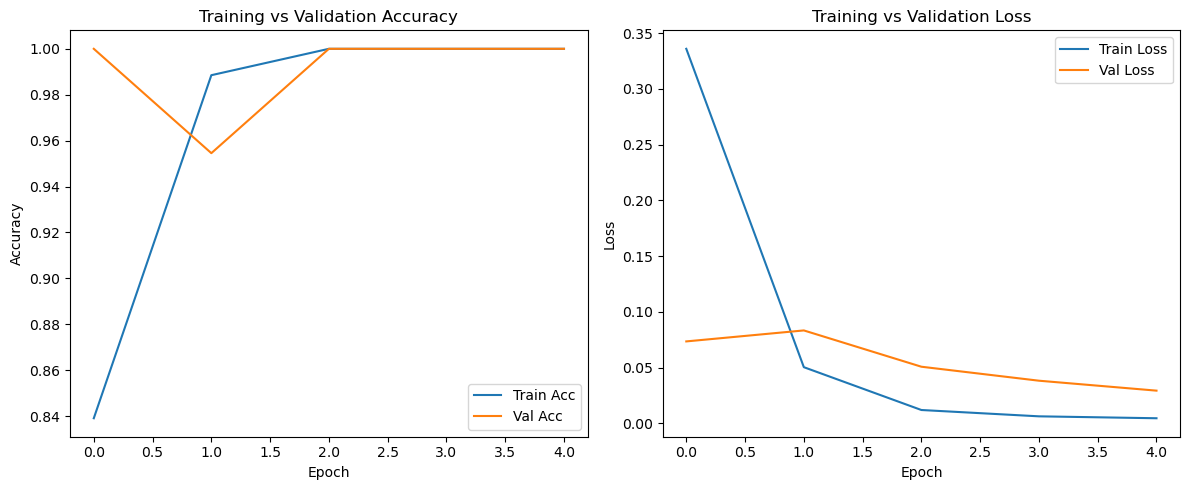

In [8]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step


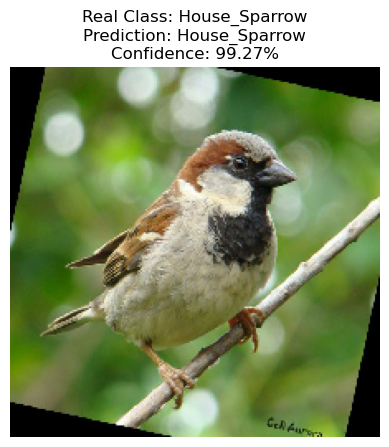

In [9]:
import random

# 隨機選擇一張圖片
idx = random.randint(0, len(data) - 1)
img = data[idx]
true_label = targets[idx]

# 預測
prediction = model.predict(np.expand_dims(img, axis=0))
pred_idx = np.argmax(prediction)
confidence = prediction[0][pred_idx]

# 類別對照
bird_classes_english = ['Acadian_Flycatcher', 'Blue_Jay', 'House_Sparrow']
bird_classes_chinese = ['褐翅鹟', '冠藍鴉', '麻雀']

# 顯示圖片與預測結果
plt.imshow(img)
plt.axis('off')
plt.title(
    f"Real Class: {bird_classes_english[true_label]}\n"
    f"Prediction: {bird_classes_english[pred_idx]}\n"
    f"Confidence: {confidence:.2%}"
)
plt.show()


In [10]:
model.save("bird_classifier_model.keras")
print("模型已儲存為 bird_classifier_model.keras")
# 載入模型（可選，用於驗證）
#from tensorflow.keras.models import load_model

# 載入 .keras 格式模型
#model = load_model('bird_species_classifier_model.keras')
#print("模型已載入")


模型已儲存為 bird_classifier_model.keras


Loading images: 100%|██████████| 109/109 [00:00<00:00, 326.27it/s]


Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step - accuracy: 0.7241 - loss: 0.6140 - val_accuracy: 1.0000 - val_loss: 0.1281
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.9885 - loss: 0.0956 - val_accuracy: 1.0000 - val_loss: 0.0301
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 1.0000 - loss: 0.0322 - val_accuracy: 1.0000 - val_loss: 0.0165
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 1.0000 - loss: 0.0153 - val_accuracy: 1.0000 - val_loss: 0.0104
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0079


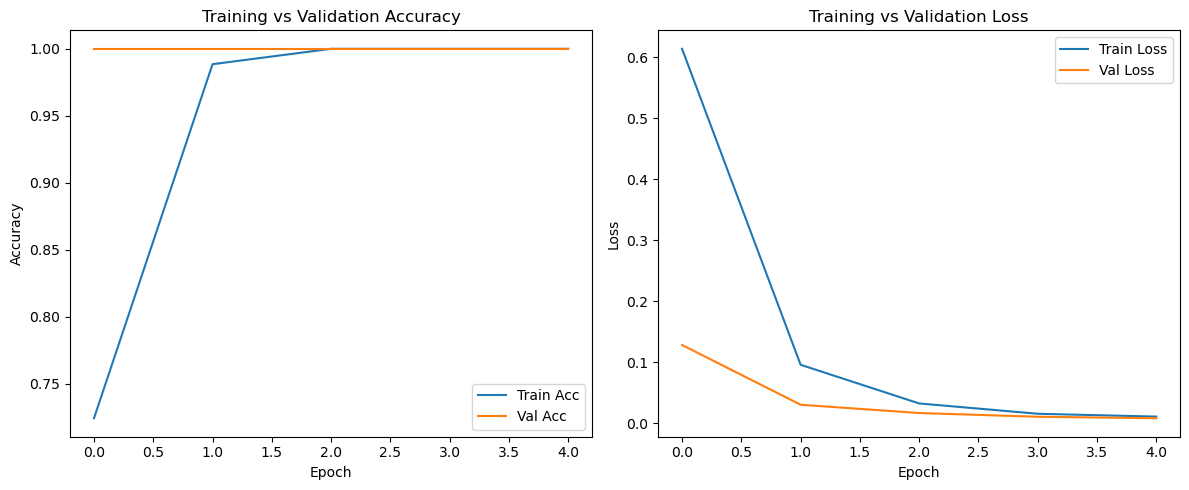

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step


Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
Glyph 20896 (\N{CJK UNIFIED IDEOGRAPH-51A0}) missing from font(s) DejaVu Sans.
Glyph 34253 (\N{CJK UNIFIED IDEOGRAPH-85CD}) missing from font(s) DejaVu Sans.
Glyph 40201 (\N{CJK UNIFIED IDEOGRAPH-9D09}) missing from font(s) DejaVu Sans.
Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.


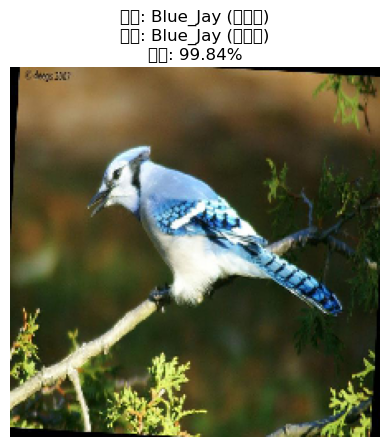

模型已儲存為 'bird_classifier_model.keras'
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


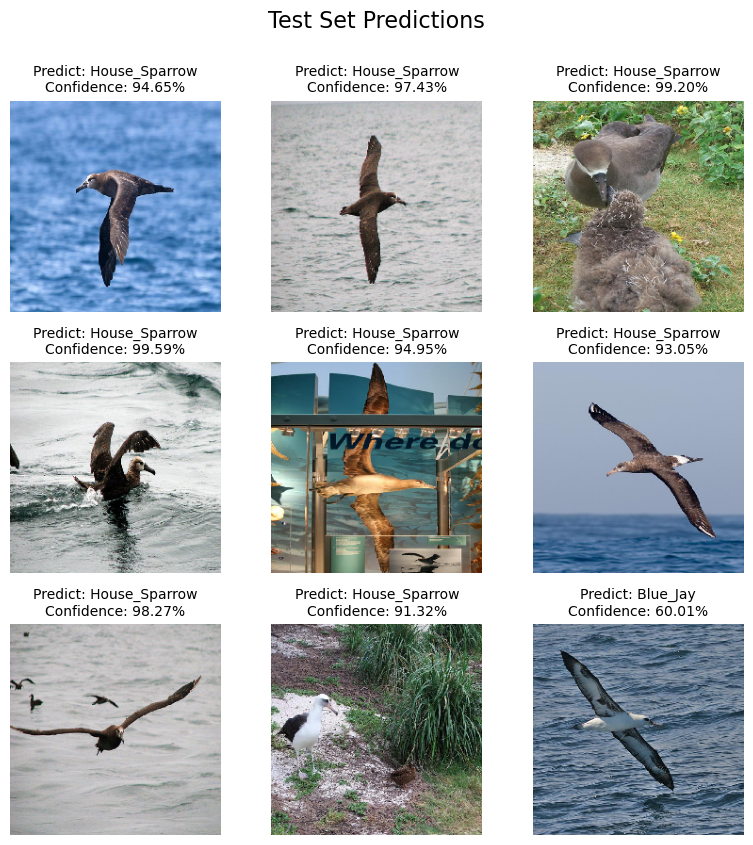

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random

# 設定類別
bird_classes_english = ['Acadian_Flycatcher', 'Blue_Jay', 'House_Sparrow']
bird_classes_chinese = ['褐翅鹟', '冠藍鴉', '麻雀']
num_classes = len(bird_classes_english)

# 資料夾與圖片尺寸
extract_dir_birds = "bird_species_data"
train_data_root = os.path.join(extract_dir_birds, 'train')
IMG_HEIGHT, IMG_WIDTH = 224, 224

# 掃描訓練資料夾，取得影像路徑與標籤
all_image_paths, all_image_labels = [], []
for f in os.listdir(train_data_root):
    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
        prefix2 = '_'.join(f.split('_')[:2])
        if prefix2 in bird_classes_english:
            label_idx = bird_classes_english.index(prefix2)
            all_image_paths.append(os.path.join(train_data_root, f))
            all_image_labels.append(label_idx)

# 載入與預處理圖片
data, targets = [], []
for img_path, label in tqdm(zip(all_image_paths, all_image_labels), total=len(all_image_paths), desc="Loading images"):
    try:
        img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = img_to_array(img) / 255.0
        data.append(img_array)
        targets.append(label)
    except Exception as e:
        print(f"Error loading {img_path}: {e}")

# 資料與標籤轉為陣列
data = np.array(data)
targets = np.array(targets)
one_hot_targets = to_categorical(targets, num_classes=num_classes)

# 分割訓練與驗證集
X_train, X_val, y_train, y_val = train_test_split(data, one_hot_targets, test_size=0.2, random_state=42)

# 建立模型
base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False

inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

# 編譯模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 訓練模型
history = model.fit(X_train, y_train, epochs=5, batch_size=8, validation_data=(X_val, y_val))

# 視覺化訓練過程
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 單張預測展示
idx = random.randint(0, len(X_val) - 1)
img = X_val[idx]
true_label = np.argmax(y_val[idx])
pred = model.predict(np.expand_dims(img, axis=0))[0]
pred_label = np.argmax(pred)
confidence = pred[pred_label]

plt.imshow(img)
plt.axis('off')
plt.title(
    f"真實: {bird_classes_english[true_label]} ({bird_classes_chinese[true_label]})\n"
    f"預測: {bird_classes_english[pred_label]} ({bird_classes_chinese[pred_label]})\n"
    f"信心: {confidence:.2%}"
)
plt.show()

# 儲存模型為 .keras
model.save("bird_classifier_model.keras")
print("模型已儲存為 'bird_classifier_model.keras'")

# 載入模型（可選，用於驗證）
#from tensorflow.keras.models import load_model

# 載入 .keras 格式模型
#model = load_model('bird_species_classifier_model.keras')
#print("模型已載入")

# 測試集預測
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 測試資料夾路徑
test_data_root = "bird_species_data/test"

# 類別對應
bird_classes_english = ['Acadian_Flycatcher', 'Blue_Jay', 'House_Sparrow']
bird_classes_chinese = ['褐翅鹟', '冠藍鴉', '麻雀']

# 載入模型
model = load_model("bird_classifier_model.keras")

# 圖片尺寸
IMG_HEIGHT, IMG_WIDTH = 224, 224

# 掃描測試集圖片路徑
test_image_paths = [
    os.path.join(test_data_root, fname)
    for fname in os.listdir(test_data_root)
    if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
]

# 顯示預測結果
num_show = min(9, len(test_image_paths))
plt.figure(figsize=(8, 8))
for i in range(num_show):
    img_path = test_image_paths[i]
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = img_to_array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, axis=0))[0]
    pred_label = np.argmax(pred)
    confidence = pred[pred_label]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(
        f"Predict: {bird_classes_english[pred_label]}\nConfidence: {confidence:.2%}",
        fontsize=10
    )

plt.tight_layout()
plt.suptitle("Test Set Predictions", fontsize=16, y=1.05)
plt.show()


In [12]:
from tensorflow.keras.optimizers import Adam

# 解凍 base_model 的所有層（讓它們可訓練）
base_model.trainable = True
print("Base model layers have been unfrozen (trainable=True).")

# 使用較小學習率來微調，避免破壞預訓練權重
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 調低學習率
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 重新訓練模型（可從之前訓練的 data 和 one_hot_targets 接續）
fine_tune_history = model.fit(
    data,
    one_hot_targets,
    epochs=5,            # 微調通常訓練少量 epochs 即可
    batch_size=8,
    validation_split=0.2
)


Base model layers have been unfrozen (trainable=True).
Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 1.0000 - loss: 0.0147 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 1.0000 - loss: 0.0155 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 1.0000 - loss: 0.0150 - val_accuracy: 1.0000 - val_loss: 0.0037


In [13]:
# Step 1: 確保 base_model 設為 trainable
base_model.trainable = True

# Step 2: 先將所有層設為非可訓練
for layer in base_model.layers:
    layer.trainable = False

# Step 3: 解凍最後 5 層
for layer in base_model.layers[-5:]:
    layer.trainable = True

# 確認哪些層是可訓練的（列出最後幾層）
print("\nTrainable layers in base_model (last 5):")
for layer in base_model.layers[-10:]:  # 顯示最後 10 層，方便對照
    print(f"{layer.name}: {'Trainable' if layer.trainable else 'Frozen'}")

# 重新編譯模型（使用較小學習率）
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 使用較小的學習率
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# 繼續訓練（Fine-tune）
fine_tune_history = model.fit(
    data,
    one_hot_targets,
    epochs=5,
    batch_size=8,
    validation_split=0.2
)



Trainable layers in base_model (last 5):
conv5_block3_1_bn: Frozen
conv5_block3_1_relu: Frozen
conv5_block3_2_pad: Frozen
conv5_block3_2_conv: Frozen
conv5_block3_2_bn: Frozen
conv5_block3_2_relu: Trainable
conv5_block3_3_conv: Trainable
conv5_block3_out: Trainable
post_bn: Trainable
post_relu: Trainable
Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0038



Loading and preprocessing images (resizing to 299x299)...


Loading and preprocessing images: 100%|██████████| 109/109 [00:00<00:00, 261.10it/s]


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,808,931 (83.19 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/3
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 309ms/step - accuracy: 0.6667 - loss: 0.7184 - val_accuracy: 1.0000 - val_loss: 0.0712
Epoch 2/3
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 1.0000 - loss: 0.0855 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 3/3
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 1/2
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 1.0000 - loss: 0.0159 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 2/2
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 1.0000 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 0.0061
共載入測試圖片數量：1173
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


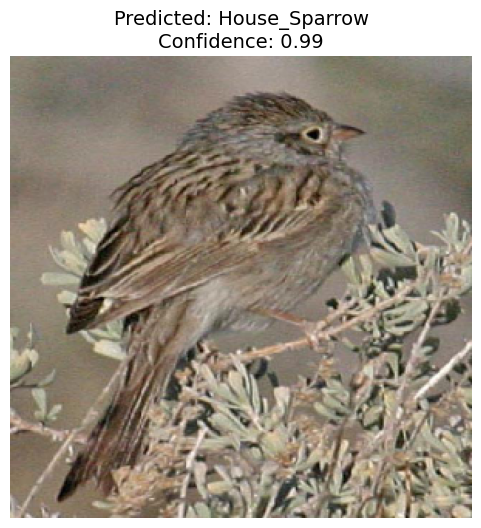

In [15]:
# 1. 匯入 InceptionV3 與預處理工具
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
# 2. 修改圖片尺寸與預處理
# 更新圖片尺寸（InceptionV3 預期 299x299）
IMG_HEIGHT = 299
IMG_WIDTH = 299

# 圖片載入與預處理
data = []
targets = []

print(f"\nLoading and preprocessing images (resizing to {IMG_HEIGHT}x{IMG_WIDTH})...")
for img_path, label in tqdm(zip(all_image_paths, all_image_labels), total=len(all_image_paths), desc="Loading and preprocessing images"):
    try:
        img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)  # 使用 InceptionV3 的預處理
        data.append(img_array)
        targets.append(label)
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")

data = np.array(data)
targets = np.array(targets)
one_hot_targets = to_categorical(targets, num_classes=num_classes)

# 3. 建構 InceptionV3 模型（不包含頂層）
base_model = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# 凍結所有 InceptionV3 層（之後可以微調）
base_model.trainable = False

# 建構分類頭
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# 4. 編譯與訓練模型
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 訓練模型
history = model.fit(
    data,
    one_hot_targets,
    epochs=3,
    batch_size=8,
    validation_split=0.2
)

# 5. （選擇性）解凍部分 InceptionV3 層微調
# 解凍最後 10 層進行微調
base_model.trainable = True
for layer in base_model.layers[:-5]:
    layer.trainable = False

# 重新編譯模型以啟用微調
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 微調訓練
fine_tune_history = model.fit(
    data,
    one_hot_targets,
    epochs=2,
    batch_size=8,
    validation_split=0.2
)

# 6. 使用訓練好的模型進行預測並視覺化結果
# 匯入必要模組
import random
import matplotlib.pyplot as plt

# 指定測試圖片資料夾
test_dir = os.path.join(extract_dir_birds, 'test')
test_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not test_images:
    print("測試集內沒有圖片，請確認資料下載正確。")
else:
    print(f"共載入測試圖片數量：{len(test_images)}")

# 隨機挑一張圖片
random_filename = random.choice(test_images)
random_path = os.path.join(test_dir, random_filename)

# 載入並預處理
img = load_img(random_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = img_to_array(img)
img_array = preprocess_input(img_array)  # 注意：InceptionV3 的預處理是 [-1, 1]
img_batch = np.expand_dims(img_array, axis=0)  # 批次維度

# 預測
predictions = model.predict(img_batch)[0]  # shape: (num_classes,)
predicted_index = np.argmax(predictions)
predicted_label = bird_classes_english[predicted_index]
predicted_chinese = bird_classes_chinese[predicted_index]
predicted_confidence = predictions[predicted_index]

# 顯示圖片與結果
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_label}\nConfidence: {predicted_confidence:.2f}", fontsize=14)
plt.show()




In [18]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences #補足序/切斷列長度
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM, GRU
# Embedding: 詞索引
# LSTM: 長短期記憶，解決長期依賴問題
# GRU: 門控循環單元，解決梯度爆炸/消失問題
import matplotlib.pyplot as plt
import numpy as np

In [19]:
max_words = 10000
(x_train , y_train),(x_test, y_test) = imdb.load_data(num_words=max_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
print(f"訓練評論筆數:{len(x_train)}")
print(f"測試評論筆數:{len(x_test)}")
print(f"訓練評論第一筆:{x_train[0]}")
print(f"訓練評論第一筆的單詞數:{len(x_train[1])}")
print(f"訓練評論第一筆的標籤:{y_train[1]}")# 0:正向 1:負向評論

訓練評論筆數:25000
測試評論筆數:25000
訓練評論第一筆:[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
訓練評論第一筆的單詞數:189
訓練評論第一筆的標籤

In [22]:
#切齊評論詞數(200個詞)
max_review_length = 200
#padding='pre' 評論詞數<200，前方補不足的0； truncating='pre' 評論詞數>200，前方截斷多餘的
x_train = pad_sequences(x_train, maxlen=max_review_length, padding='pre', truncating='pre')
x_test = pad_sequences(x_test, maxlen=max_review_length, padding='pre', truncating='pre')
x_train[1]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          1,  194, 1153,  194, 8255,   78,  228,    5,    6, 1463, 4369,
       5012,  134,   26,    4,  715,    8,  118, 1634,   14,  394,   20,
         13,  119,  954,  189,  102,    5,  207,  110, 3103,   21,   14,
         69,  188,    8,   30,   23,    7,    4,  249,  126,   93,    4,
        114,    9, 2300, 1523,    5,  647,    4,  116,    9,   35, 8163,
          4,  229,    9,  340, 1322,    4,  118,    9,    4,  130, 4901,
         19,    4, 1002,    5,   89,   29,  952,   46,   37,    4,  455,
          9,   45,   43,   38, 1543, 1905,  398,    4, 1649,   26, 6853,
          5,  163,   11, 3215,    2,    4, 1153,    9,  194,  775,    7,
       8255,    2,  349, 2637,  148,  605,    2, 8003,   15,  123,  125,
         68,    2, 6853,   15,  349,  165, 4362,   98,    5,    4,  228,
          9,   43,    2, 1157,   15,  299,  120,    5,  120,  174,   11,
        220,  175,  136,   50,    9, 4373,  228, 82

In [23]:
model_rnn = Sequential()
model_rnn.add(Input(shape=(max_review_length,)))
model_rnn.add(Embedding(input_dim=max_words, output_dim=128))
model_rnn.add(SimpleRNN(units=128))
model_rnn.add(Dense(units=1, activation='sigmoid'))

In [24]:
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
history_rnn = model_rnn.fit(x_train, y_train, epochs=3, batch_size=300, validation_data=(x_test, y_test))

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6045 - loss: 0.6611 - val_accuracy: 0.6825 - val_loss: 0.6064
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.7797 - loss: 0.4742 - val_accuracy: 0.7997 - val_loss: 0.4442
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.9028 - loss: 0.2445 - val_accuracy: 0.8321 - val_loss: 0.4094


In [26]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,939,077 (15.03 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,626,052 (10.02 MB)

In [28]:
loss_rnn, accuracy_rnn = model_rnn.evaluate(x_test, y_test)
print(f"SimpleRNN LossL {loss_rnn:.3f}")
print(f"SimpleRNN accuracy {accuracy_rnn:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8321 - loss: 0.4094
SimpleRNN LossL 0.409
SimpleRNN accuracy 0.832


In [29]:
#LSTM
model_lstm = Sequential()
model_lstm.add(Input(shape=(max_review_length,)))
model_lstm.add(Embedding(input_dim=max_words, output_dim=128))
model_lstm.add(LSTM(units=128))
model_lstm.add(Dense(units=1, activation='sigmoid'))

In [30]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_rnn = model_lstm.fit(x_train, y_train, epochs=3, batch_size=300, validation_data=(x_test, y_test))
model_lstm.summary()

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.7015 - loss: 0.5701 - val_accuracy: 0.8351 - val_loss: 0.3769
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 512ms/step - accuracy: 0.8781 - loss: 0.2992 - val_accuracy: 0.8697 - val_loss: 0.3143
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 533ms/step - accuracy: 0.9182 - loss: 0.2162 - val_accuracy: 0.8552 - val_loss: 0.3353


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,235,141 (16.16 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,823,428 (10.77 MB)

In [31]:
loss_lstm, accuracy_lstm = model_lstm.evaluate(x_test, y_test)
print(f"LSTM LossL {loss_lstm:.3f}")
print(f"LSTM accuracy {accuracy_lstm:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8552 - loss: 0.3353
LSTM LossL 0.335
LSTM accuracy 0.855


In [32]:
#GRU
model_gru = Sequential()
model_gru.add(Input(shape=(max_review_length,)))
model_gru.add(Embedding(input_dim=max_words, output_dim=128))
model_gru.add(GRU(units=128))
model_gru.add(Dense(units=1, activation='sigmoid'))

In [33]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_rnn = model_gru.fit(x_train, y_train, epochs=3, batch_size=30, validation_data=(x_test, y_test))
model_gru.summary()

Epoch 1/3
834/834 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.7835 - loss: 0.4479 - val_accuracy: 0.8611 - val_loss: 0.3293
Epoch 2/3
834/834 ━━━━━━━━━━━━━━━━━━━━ 62s 74ms/step - accuracy: 0.9124 - loss: 0.2196 - val_accuracy: 0.8858 - val_loss: 0.2775
Epoch 3/3
834/834 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.9538 - loss: 0.1288 - val_accuracy: 0.8762 - val_loss: 0.3156


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,137,605 (15.78 MB)

 Trainable params: 1,379,201 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,758,404 (10.52 MB)

In [34]:
loss_gru, accuracy_gru = model_gru.evaluate(x_test, y_test)
print(f"GRU LossL {loss_gru:.3f}")
print(f"GRU accuracy {accuracy_gru:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8762 - loss: 0.3156
GRU LossL 0.316
GRU accuracy 0.876


In [40]:
#RNN文言文生成(1)
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Embedding,Input
from tensorflow.keras.preprocessing.text import  Tokenizer#文字轉數值編碼
from tensorflow.keras.preprocessing.sequence import pad_sequences
import random

In [44]:
# 原始文言文文本：此段選自《棋鬼》文言短篇故事，描寫將軍與棋魂之間的奇異相遇。

text = """
揚州督同將軍梁公，解組鄉居，日攜棋酒，遊林丘間。會九日登高與客弈，忽有一人來，遁巡局側，耽玩不去。
弈罷，怪者乃消失，眾人以為鬼魅。及暮，將軍夜夢，見有文士索棋，臨軒而觀，言：「棋未終，須待一著。」公驚醒，起卻空室。
次日，督行訪山寺，問山僧：「近有異人手善弈耶？」僧云：「近日林中似有客，常來觀者，未曾落子。」
公聞而怦然，乃攜棋弈之，果不見人影，唯聽風聲漾漾，似有人聲回。
後數日，每至暮色，林中必傳棋聲，杓音斷續，似有一方。將軍以為神異，乃鑿一室於林中，置棋局相待。
暮至，果見一衣冠文士，面如白玉，步至棋前，居坐若懸，指著棋子，長吁云：「此子著未定，落子不當，我負爾等。」
聲音悠悠，忽遠忽近，如夢中語。梁公圍觀者眾，亦自惶恐，不敢逼近。
文士指畢，便與聲俱滅。眾人探看，林深無跡，唯見棋局仍立。
梁公自此不復弈，而林中棋聲斷。傳聞此「棋鬼」者，守舊棋藝數百年之靈，見將軍棋高者，遂來助局。
然其心尚未捨，故常現於暮。後世山人談此奇事者，莫不毛骨悚然，為之動容。
"""

# 匯入正則表達式模組（regular expression），用於依據標點符號切分句子。
import re

# 使用正則表達式將文章依據「句末標點」斷句。
# (?<=[。！？]) 是「正向前瞻」，表示在這些標點符號後切開句子
sentences = re.split(r'(?<=[。！？])', text)

# 去除每個句子開頭與結尾空白，並以換行符號分隔句子
cleaned_text = "\n".join([s.strip() for s in sentences if s.strip()])

# 將處理好的句子寫入檔案中，編碼使用 UTF-8，確保中文顯示正確。
with open("棋鬼_文言文_cleaned.txt", "w", encoding="utf-8") as f:
    f.write(cleaned_text)


In [46]:
# 使用內建 open() 函數讀取檔案，路徑為我們在前一節儲存的「棋鬼_文言文_cleaned.txt」
# "r" 代表讀取模式，encoding 設定為 "utf-8"，確保中文文字正確解碼。
with open("棋鬼_文言文_cleaned.txt", "r", encoding="utf-8") as f:
    text = f.read()  # 將整個文字內容讀入變數 text 中


In [47]:
#文字分詞與序列化(字級處理)
tokenizer = Tokenizer(char_level=True) #char_level=True 以字為單位(而非詞)

In [49]:
# 初始化一個 tokenizer，並設定 char_level=True，表示我們以「字」為單位進行處理（而不是詞）
tokenizer = Tokenizer(char_level=True)

# 將文本中的所有字詞統一編號（建立字典），這個步驟會自動去除重複字元
tokenizer.fit_on_texts([text])  # 參數格式需為 list of string

# 將文字轉換成數字序列（每個字會對應到一個整數）
sequences = tokenizer.texts_to_sequences([text])[0]  # [0] 是因為回傳是巢狀 list

# 建立字彙大小（加 1 是為了保留 0 給 padding）
vocab_size = len(tokenizer.word_index) + 1

# ------------- 建立 RNN 訓練資料 ------------------

# 序列長度：每 20 個字作為輸入，預測第 21 個字
seq_length = 20
X = []  # 輸入資料（多個 20 字長度序列）
y = []  # 輸出資料（對應每個序列的下一字）

# 使用滑動視窗建立資料對（X: 20字, y: 第21字）
for i in range(seq_length, len(sequences)):
    X.append(sequences[i - seq_length:i])  # 從 i-20 到 i-1，做為輸入序列
    y.append(sequences[i])                 # 第 i 個字是目標字（要預測的）

# 轉為 NumPy 陣列，方便後續模型訓練
X = np.array(X)

# 將 y 轉為 one-hot 向量：必要格式，才能對應 categorical_crossentropy 損失函數
y = tf.keras.utils.to_categorical(y, num_classes=vocab_size)


In [50]:
# 使用 Keras 的順序模型：從輸入到輸出依序堆疊
model = Sequential()

# 第一層：嵌入層（Embedding）
# 將輸入的整數序列轉換成稠密向量（詞嵌入 Embedding）
# - input_dim: 字彙表大小
# - output_dim: 每個字要轉換成的向量維度
model.add(Embedding(input_dim=vocab_size, output_dim=64))

# 第二層：LSTM（長短期記憶網路）
# - 128 是記憶單元的個數（神經元數量），越大模型越複雜但也更耗時
# - 預設 return_sequences=False，表示只輸出最後時間步的結果
model.add(LSTM(128))

# 第三層：全連接輸出層（Dense），輸出空間為 vocab_size 大小（每個字的機率）
# - activation='softmax'：將輸出轉換為機率分佈
model.add(Dense(vocab_size, activation='softmax'))

# 編譯模型
# - loss: 使用類別交叉熵（categorical_crossentropy）作為損失函數
# - optimizer: 使用 Adam 優化器進行梯度調整
model.compile(loss='categorical_crossentropy', optimizer='adam')

# 顯示模型結構摘要
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
# 模型訓練
# - X: 訓練輸入（每筆是 20 字長度的字元編碼序列）
# - y: 訓練標籤（對應每個輸入的下一個字，已轉為 one-hot）
# - epochs: 訓練次數，建議先設 100~300 測試效果再加大
# - batch_size: 每次訓練的樣本數
# - verbose: 顯示訓練進度（1 為顯示 bar）
model.fit(X, y, epochs=300, batch_size=10, verbose=1)


Epoch 1/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1789 
Epoch 2/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8397
Epoch 3/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7618
Epoch 4/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7073
Epoch 5/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6397
Epoch 6/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5235
Epoch 7/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3527
Epoch 8/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1727
Epoch 9/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0102
Epoch 10/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8082
Epoch 11/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6273
Epoch 12/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4397
Epoch 13/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2371
Epoch 14/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0418
Epoch 15/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8670
Epo

In [54]:
# 設定生成文本的起始字串（種子文本），模型將從此開始預測後續文字
seed = "林中暮色"

# 呼叫先前定義的文字生成函數，生成長度為80字的文言文文本
# temperature設定為0.7，表示生成時稍微偏向保守但仍帶有一定多樣性
generated_text = generate_text(seed, length=80, temperature=0.7)

# 將生成的文本印出來，包含起始種子文本和模型生成的後續字元
print(generated_text)


NameError: name 'generate_text' is not defined

In [55]:
!pip install -q gradio transformers torch jieba opencc-python-reimplemented


  DEPRECATION: Building 'jieba' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'jieba'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [56]:
import gradio as gr
import torch, re
from transformers import BertTokenizer, GPT2LMHeadModel, TextGenerationPipeline
import jieba
from opencc import OpenCC  # 用於簡轉繁體


In [57]:
# 載入 GPT-2 文言模型與 tokenizer
tokenizer = BertTokenizer.from_pretrained("uer/gpt2-chinese-ancient")
model = GPT2LMHeadModel.from_pretrained("uer/gpt2-chinese-ancient")
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
device = 0 if torch.cuda.is_available() else -1
textgen = TextGenerationPipeline(model=model, tokenizer=tokenizer, device=device)


tokenizer_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

`huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MSI-NB\.cache\huggingface\hub\models--uer--gpt2-chinese-ancient. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development


vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/434M [00:00<?, ?B/s]

Device set to use cpu


In [58]:
# 初始化繁體轉換工具
cc = OpenCC('s2t')


In [59]:
def clean_generated(text: str) -> str:
    # 移除多餘空白
    text = re.sub(r'\s+', '', text)
    # 合併連續標點（例如，，，）
    text = re.sub(r'[，。！？、]{2,}', lambda m: m.group(0)[0], text)
    return text


In [60]:
def generate_response(prompt: str,
        max_new_tokens: int = 80,
        temperature: float = 0.7,
        top_p: float = 0.8,
        top_k: int = 50,
        repetition_penalty: float = 1.2):
    # 使用 GPT-2 模型生成古文
    raw = textgen(prompt,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        repetition_penalty=repetition_penalty,
        do_sample=True,
        truncation=True)[0]['generated_text']
    # 清理並轉為繁體中文
    cleaned = clean_generated(raw)
    trad = cc.convert(cleaned)
    return trad


In [61]:
gr.Interface(
    fn=generate_response,
    inputs=[
        gr.Textbox(lines=2, placeholder="如：林中暮色，忽聞棋聲"),
        gr.Slider(20, 200, value=80, step=10, label="生成長度"),
        gr.Slider(0.1, 1.5, value=0.7, step=0.1, label="創造力"),
        gr.Slider(0.1, 1.0, value=0.8, step=0.1, label="top_p"),
        gr.Slider(10, 100, value=50, step=5, label="top_k"),
        gr.Slider(1.0, 2.0, value=1.2, step=0.1, label="重複懲罰")
    ],
    outputs=gr.Textbox(label="【棋鬼曰】繁體生成"),
    title="🪶 文言文生成器（繁體中文）",
    description="輸入提示，模型生成古文並輸出繁體版本。",
    allow_flagging="never"
).launch()


TypeError: BlockContext.__init__() got an unexpected keyword argument 'allow_flagging'